# Radiogenomic Recoverability — Image-Identifiable Genomic Subspaces

This notebook implements the linear–Gaussian model of `main.tex` on a pair of
[`AnnData`](https://anndata.readthedocs.io/) objects:

- **genomics** — a patient × genomics matrix $\mathbf{G}\in\mathbb{R}^{n\times p}$
- **imaging** — a patient × imaging matrix $\mathbf{X}\in\mathbb{R}^{n\times d}$

Set the two `.h5ad` paths in the configuration cell. If they are absent, the
notebook falls back to a **synthetic dataset with known ground truth**, so every
estimate can be checked against the value it is supposed to recover.

The question is not *"does imaging predict gene $j$?"* but *"which low-dimensional
genomic subspaces are image-identifiable?"* — answered by the **recoverability
spectrum** $\{\rho_i^2\}$ and the genomic directions $\{a_i\}$ that achieve it.
All heavy lifting lives in the `rgit` package; the notebook just orchestrates and
visualizes.

## The model in brief

Genomics has a Gaussian prior and imaging is a noisy linear readout of it:

$$G \sim \mathcal{N}(0,\Sigma_G), \qquad X \mid G \sim \mathcal{N}(AG,\ \sigma^2 I_d).$$

Every quantity below is then closed-form (see `main.tex` for derivations):

| quantity | formula | meaning |
|---|---|---|
| Bayes-optimal predictor | $\hat g(x)=\Sigma_{GX}\Sigma_X^{-1}x$ | best possible $E[g\mid x]$ |
| posterior covariance | $\Sigma_{G\mid X}=\Sigma_G-\Sigma_{GX}\Sigma_X^{-1}\Sigma_{XG}$ | hard floor on residual uncertainty |
| recoverability of $a_i$ | $R_i=\rho_i^2$ | $1-$ fraction of variance surviving imaging |
| mutual information | $I(G;X)=-\tfrac12\sum_i\log(1-\rho_i^2)$ | total information budget |

The recoverability directions solve a generalized eigenproblem that **coincides
with canonical correlation analysis** between $\mathbf{G}$ and $\mathbf{X}$, so we
only ever estimate the three second moments $\Sigma_G,\Sigma_X,\Sigma_{GX}$ —
never $A$ or $\sigma^2$ individually.

## 1 · Configuration and imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# --- make the rgit package importable whether or not it is pip-installed ---
REPO_ROOT = Path.cwd().parent.parent if Path.cwd().name == "out" else Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import rgit

In [2]:
# --- paths to the two AnnData objects -------------------------------------
GENOMICS_H5AD = REPO_ROOT / "data" / "tcga_kirc" / "genomics" / "mutated_genes.h5ad"
IMAGING_H5AD  = REPO_ROOT / "data" / "tcga_kirc" / "imaging" / "tumor_radiomics.h5ad"
USE_SYNTHETIC = not (GENOMICS_H5AD.exists() and IMAGING_H5AD.exists())

# --- analysis settings ----------------------------------------------------
SEED                   = 0
N_COMPONENTS            = 12     # canonical directions to estimate / display
GENOMICS_PCA_THRESHOLD  = 300    # PCA-reduce genomics when p exceeds this
GENOMICS_PCA_NCOMP      = 100    # target dimension of the genomic PCA
N_FOLDS                 = 5      # cross-validation folds
N_PERM                  = 200    # permutations for the significance test

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(SEED)
print(f"repo root         : {REPO_ROOT}")
print(f"using synthetic   : {USE_SYNTHETIC}")

repo root         : /home/jrich/Desktop/rgit
using synthetic   : False


## 2 · Load the data

`load_data()` reads the two `.h5ad` files when they exist. Otherwise it draws a
synthetic dataset from the probabilistic-CCA generative model
($Z\in\mathbb{R}^k$ shared latent, modality-private anisotropic noise) and wraps
it in `AnnData` objects with the same interface — including a deliberately
shuffled patient order on the imaging side, so the alignment step is exercised.
When synthetic, `truth` carries the generative parameters for later validation.

In [3]:
def load_data():
    '''Return (genomics_adata, imaging_adata, truth_or_None).'''
    if not USE_SYNTHETIC:
        gen = ad.read_h5ad(GENOMICS_H5AD)
        img = ad.read_h5ad(IMAGING_H5AD)

        # keep only the intersection of patients with both genomics and imaging data
        common_patients = gen.obs_names.intersection(img.obs_names)
        gen = gen[common_patients]
        img = img[common_patients]

        # filter vars in gen that are not in at least 3 patients to reduce noise
        gen = gen[:, (gen.X > 0).sum(axis=0) >= 3]

        print(f"loaded genomics {gen.shape} and imaging {img.shape} from disk")
        return gen, img, None

    # ---- synthetic fallback with known ground truth ----
    G, X, truth = rgit.make_synthetic_radiogenomics(
        n=800, p=80, d=40, k=6, random_state=SEED,
    )
    patients = np.array([f"P{i:04d}" for i in range(G.shape[0])])
    genes    = [f"GENE{i:04d}" for i in range(G.shape[1])]
    feats    = [f"radiomic_{i:03d}" for i in range(X.shape[1])]

    gen = ad.AnnData(
        X=G, obs=pd.DataFrame(index=patients),
        var=pd.DataFrame(index=genes),
    )
    # shuffle imaging patient order to make alignment non-trivial
    order = rng.permutation(G.shape[0])
    img = ad.AnnData(
        X=X[order], obs=pd.DataFrame(index=patients[order]),
        var=pd.DataFrame(index=feats),
    )
    print(f"synthetic genomics {gen.shape} and imaging {img.shape} "
          f"(true shared rank k={truth['k']})")

    gen.write_h5ad(str(GENOMICS_H5AD).replace(".h5ad", "_synthetic.h5ad"))
    img.write_h5ad(str(IMAGING_H5AD).replace(".h5ad", "_synthetic.h5ad"))
    
    return gen, img, truth


genomics_adata, imaging_adata, truth = load_data()

loaded genomics (131, 633) and imaging (131, 107) from disk


## 3 · Align patients and preprocess

Steps:

1. **Align** on the intersection of `obs_names` so both matrices are
   patient-aligned, row for row.
2. **Standardize** each feature (z-score) within each modality.
3. **Optionally PCA-reduce genomics** when $p$ is large — the manuscript's rank
   limit (Prop. 6) says imaging can only expose a low-dimensional projection of
   genomics, so little is lost provided the retained dimension exceeds the
   recoverable rank. We keep the `PCA` object to back-project genomic directions
   to gene space for interpretation.

In [4]:
# 1 · align on shared patients --------------------------------------------
shared = genomics_adata.obs_names.intersection(imaging_adata.obs_names)
shared = pd.Index(sorted(shared))
genomics_adata = genomics_adata[shared].copy()
imaging_adata  = imaging_adata[shared].copy()
assert (genomics_adata.obs_names == imaging_adata.obs_names).all()
print(f"{len(shared)} patients shared between modalities")

# 2 · standardize each modality -------------------------------------------
G_raw = rgit.to_dense(genomics_adata.X)
X_raw = rgit.to_dense(imaging_adata.X)
G_std = StandardScaler().fit_transform(G_raw)
X_std = StandardScaler().fit_transform(X_raw)

# 3 · optional genomic dimension reduction --------------------------------
if G_std.shape[1] > GENOMICS_PCA_THRESHOLD:
    n_pc = min(GENOMICS_PCA_NCOMP, *G_std.shape)
    pca_g = PCA(n_components=n_pc, random_state=SEED).fit(G_std)
    G_model = pca_g.transform(G_std)
    genomic_space = f"{n_pc} genomic PCs"
else:
    pca_g = None
    G_model = G_std
    genomic_space = "standardized genes"

X_model = X_std
gene_names = np.asarray(genomics_adata.var_names)

def to_gene_loadings(dirs):
    '''Map directions in the modeling space back to (standardized) gene space.'''
    return pca_g.components_.T @ dirs if pca_g is not None else dirs

print(f"genomics modeled in : {genomic_space}  -> G {G_model.shape}")
print(f"imaging  modeled in : standardized features -> X {X_model.shape}")

131 patients shared between modalities
genomics modeled in : 100 genomic PCs  -> G (131, 100)
imaging  modeled in : standardized features -> X (131, 107)


## 4 · Fit the recoverability model

`rgit.fit_recoverability` forms regularized covariances $\hat\Sigma_G,
\hat\Sigma_X,\hat\Sigma_{GX}$ (Ledoit–Wolf shrinkage by default), builds the
whitened transfer operator $M=\hat\Sigma_G^{-1/2}\hat\Sigma_{GX}\hat\Sigma_X^{-1/2}$,
and reads the canonical correlations $\rho_i$ off its SVD. This *is* regularized
CCA — the recoverability program and CCA are the same computation.

In [5]:
fit = rgit.fit_recoverability(G_model, X_model, n_components=N_COMPONENTS)

spectrum = pd.DataFrame({
    "component":       np.arange(1, fit.n_components + 1),
    "rho":             fit.rho,
    "recoverability":  fit.recoverability,   # R_i = rho_i^2  (in-sample)
})
print(f"mutual information  I(G;X) = {fit.mutual_information():.2f} nats "
      f"({fit.mutual_information() / np.log(2):.2f} bits)")
spectrum.round(4)

mutual information  I(G;X) = 112.02 nats (161.62 bits)


,component,rho,recoverability
0,1,1.0000,1.0000
1,2,1.0000,1.0000
2,3,1.0000,1.0000
3,4,1.0000,1.0000
4,5,1.0000,1.0000
5,6,1.0000,1.0000
6,7,1.0000,1.0000
7,8,1.0000,1.0000
8,9,0.9726,0.9459
9,10,0.9413,0.8861


## 5 · Imaging covariance decomposition

The model splits imaging covariance additively,
$\Sigma_X = \underbrace{A\Sigma_G A^\top}_{\text{genomics-driven}} + \underbrace{\sigma^2 I_d}_{\text{irreducible}}$.
`rgit.imaging_variance_explained` reports the genomics-driven share,
$\operatorname{tr}(\Sigma_{XG}\Sigma_G^{-1}\Sigma_{GX})/\operatorname{tr}(\Sigma_X)$.

fraction of imaging variance attributable to genomics: 0.926
irreducible (genomics-independent) share            : 0.074


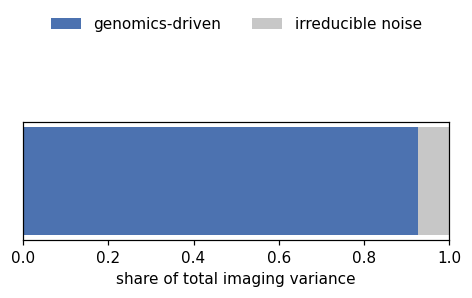

In [6]:
frac, signal_cov = rgit.imaging_variance_explained(fit)
print(f"fraction of imaging variance attributable to genomics: {frac:.3f}")
print(f"irreducible (genomics-independent) share            : {1 - frac:.3f}")

fig, ax = plt.subplots(figsize=(5, 1.4))
ax.barh([0], [frac], color="#4C72B0", label="genomics-driven")
ax.barh([0], [1 - frac], left=[frac], color="#C7C7C7", label="irreducible noise")
ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_xlabel("share of total imaging variance")
ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, 2.0), frameon=False)
ax.grid(False); plt.show()

## 6 · The recoverability spectrum

Each canonical direction $a_i$ has recoverability $R_i=\rho_i^2\in[0,1]$:
$R_i=0$ means imaging carries nothing about that genomic direction, $R_i=1$ means
it is pinned down exactly. The number of appreciably non-zero $R_i$ is the
**dimension of the image-identifiable genomic subspace**.

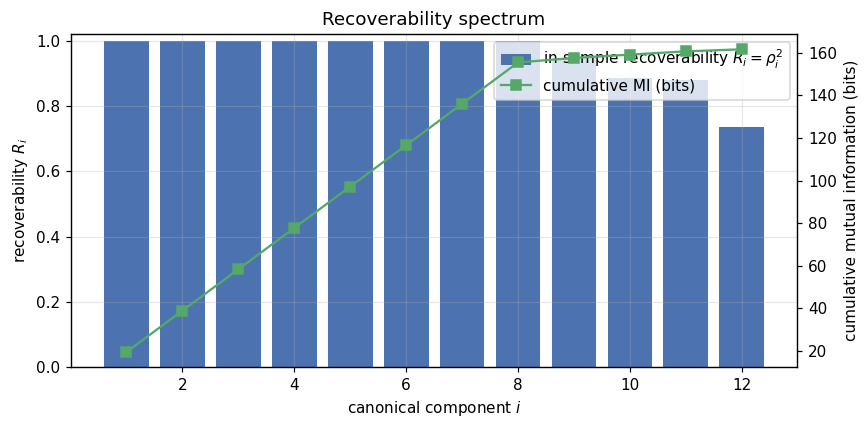

In [7]:
fig, ax1 = plt.subplots(figsize=(8, 4))
comps = spectrum["component"]
ax1.bar(comps, spectrum["recoverability"], color="#4C72B0",
        label="in-sample recoverability $R_i=\\rho_i^2$")
if truth is not None:
    rho_true, R_true = rgit.true_recoverability(truth)
    ax1.plot(np.arange(1, min(len(R_true), N_COMPONENTS) + 1),
             R_true[:N_COMPONENTS], "o--", color="#C44E52",
             label="ground-truth $R_i$")
ax1.set_xlabel("canonical component $i$")
ax1.set_ylabel("recoverability $R_i$")
ax1.set_ylim(0, 1.02)

ax2 = ax1.twinx()
ax2.plot(comps, np.cumsum(-0.5 * np.log1p(-fit.rho ** 2)) / np.log(2),
         "s-", color="#55A868", label="cumulative MI (bits)")
ax2.set_ylabel("cumulative mutual information (bits)")
ax2.grid(False)
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labs  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labs, loc="upper right", frameon=True)
ax1.set_title("Recoverability spectrum")
plt.tight_layout(); plt.show()

## 7 · Mutual information budget

$I(G;X)=\sum_i\tfrac12\log(1+\mathrm{SNR}_i)$ — each image-visible genomic
direction contributes $\tfrac12\log(1/(1-\rho_i^2))$ nats. Directions with low
signal-to-noise add almost nothing, regardless of how many genes load on them.

total I(G;X)      : 112.025 nats / 161.618 bits
top component     : 13.469 nats
share in top 6 comps: 72.1%


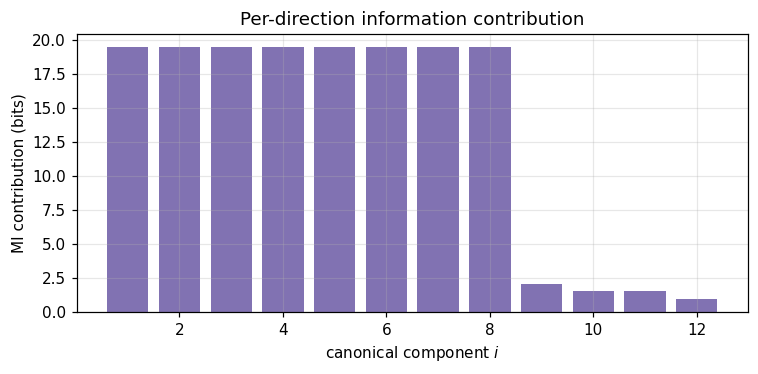

In [8]:
mi_per = -0.5 * np.log1p(-fit.rho ** 2)            # nats per component
print(f"total I(G;X)      : {mi_per.sum():.3f} nats / {mi_per.sum()/np.log(2):.3f} bits")
print(f"top component     : {mi_per[0]:.3f} nats")
print(f"share in top {min(6, fit.n_components)} comps: "
      f"{mi_per[:6].sum() / mi_per.sum():.1%}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(spectrum["component"], mi_per / np.log(2), color="#8172B2")
ax.set_xlabel("canonical component $i$")
ax.set_ylabel("MI contribution (bits)")
ax.set_title("Per-direction information contribution")
plt.tight_layout(); plt.show()

## 8 · Bayes-optimal predictor and the posterior floor

`rgit.posterior` returns the optimal linear map $B$ ($\,\hat g(x)=Bx\,$) and the
posterior covariance $\Sigma_{G\mid X}$ — the hard floor on residual genomic
uncertainty that **no estimator can beat**. We hold out a test split, predict
genomics from imaging, and check the leading canonical genomic score.

held-out R^2, leading genomic direction : -46.149
median posterior variance retained      : 0.792


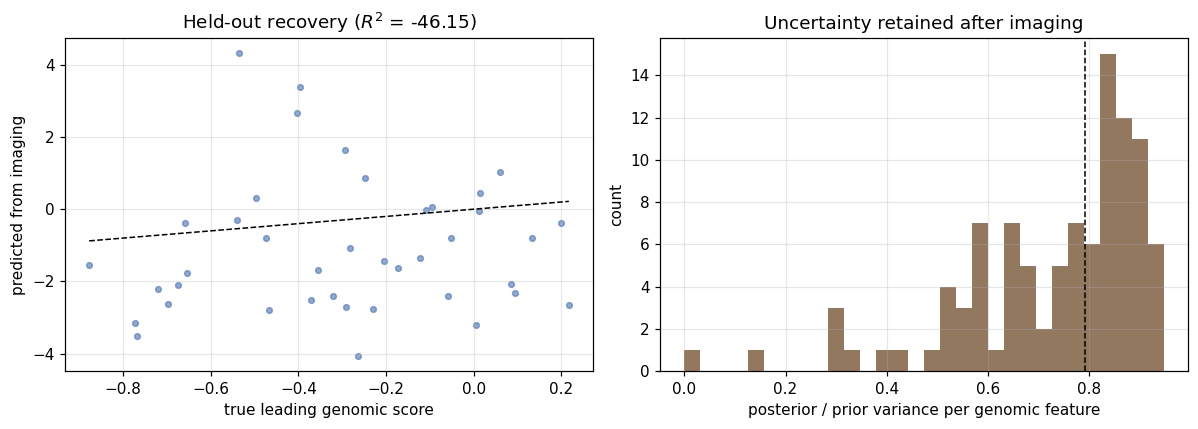

In [9]:
idx = np.arange(G_model.shape[0])
tr, te = train_test_split(idx, test_size=0.3, random_state=SEED)

fit_tr = rgit.fit_recoverability(G_model[tr], X_model[tr], n_components=N_COMPONENTS)
B, Sgcx = rgit.posterior(fit_tr)

# predict genomics from imaging on the held-out split
G_te_c   = G_model[te] - fit_tr.g_mean
X_te_c   = X_model[te] - fit_tr.x_mean
G_te_hat = X_te_c @ B.T

a1            = fit_tr.genomic_dirs[:, 0]               # leading genomic direction
score_true    = G_te_c   @ a1
score_pred    = G_te_hat @ a1
ss_res        = np.sum((score_true - score_pred) ** 2)
ss_tot        = np.sum((score_true - score_true.mean()) ** 2)
r2_heldout    = 1 - ss_res / ss_tot

# variance retained after observing imaging, per genomic feature
var_ratio = np.clip(np.diag(Sgcx) / np.diag(fit_tr.Sg), 0, 1)
print(f"held-out R^2, leading genomic direction : {r2_heldout:.3f}")
print(f"median posterior variance retained      : {np.median(var_ratio):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(score_true, score_pred, s=14, alpha=0.6, color="#4C72B0")
lim = [score_true.min(), score_true.max()]
axes[0].plot(lim, lim, "k--", lw=1)
axes[0].set_xlabel("true leading genomic score")
axes[0].set_ylabel("predicted from imaging")
axes[0].set_title(f"Held-out recovery ($R^2$ = {r2_heldout:.2f})")

axes[1].hist(var_ratio, bins=30, color="#937860")
axes[1].axvline(np.median(var_ratio), color="k", ls="--", lw=1)
axes[1].set_xlabel("posterior / prior variance per genomic feature")
axes[1].set_ylabel("count")
axes[1].set_title("Uncertainty retained after imaging")
plt.tight_layout(); plt.show()

## 9 · Image-identifiable genomic directions

The recoverability eigenproblem returns the genomic directions $a_i$ imaging
sees best. Reading their loadings back onto genes answers *which biology is
image-identifiable* — leading directions typically align with coarse, spatially
expressed programs rather than individual transcripts.

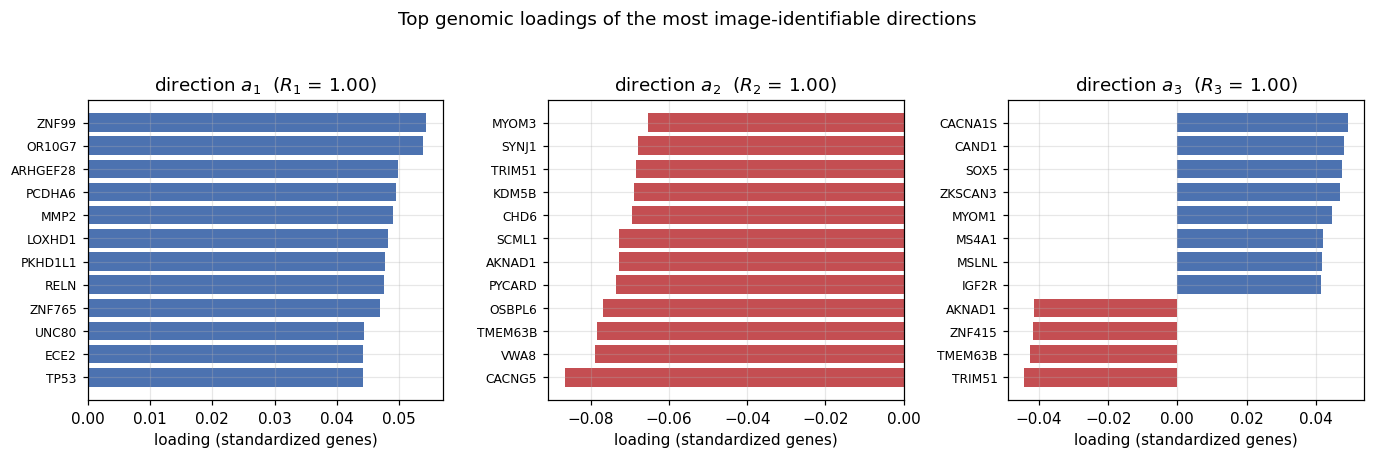

In [10]:
gene_dirs = to_gene_loadings(fit.genomic_dirs)        # (n_genes, n_components)
n_show = min(3, fit.n_components)
top_k  = 12

fig, axes = plt.subplots(1, n_show, figsize=(4.2 * n_show, 4), sharey=False)
axes = np.atleast_1d(axes)
for i in range(n_show):
    load = gene_dirs[:, i]
    order = np.argsort(-np.abs(load))[:top_k]
    order = order[np.argsort(load[order])]
    colors = ["#C44E52" if v < 0 else "#4C72B0" for v in load[order]]
    axes[i].barh(np.arange(top_k), load[order], color=colors)
    axes[i].set_yticks(np.arange(top_k))
    axes[i].set_yticklabels(gene_names[order], fontsize=8)
    axes[i].set_title(f"direction $a_{{{i+1}}}$  ($R_{{{i+1}}}$ = {fit.recoverability[i]:.2f})")
    axes[i].set_xlabel("loading (standardized genes)")
fig.suptitle("Top genomic loadings of the most image-identifiable directions", y=1.03)
plt.tight_layout(); plt.show()

## 10 · Honest recoverability — cross-validation

In-sample $\rho_i^2$ is biased upward. `rgit.cross_validated_recoverability`
estimates the canonical directions on each training fold and reports the
**out-of-sample** squared correlation of the projected scores. The gap to the
in-sample curve is the overfitting.

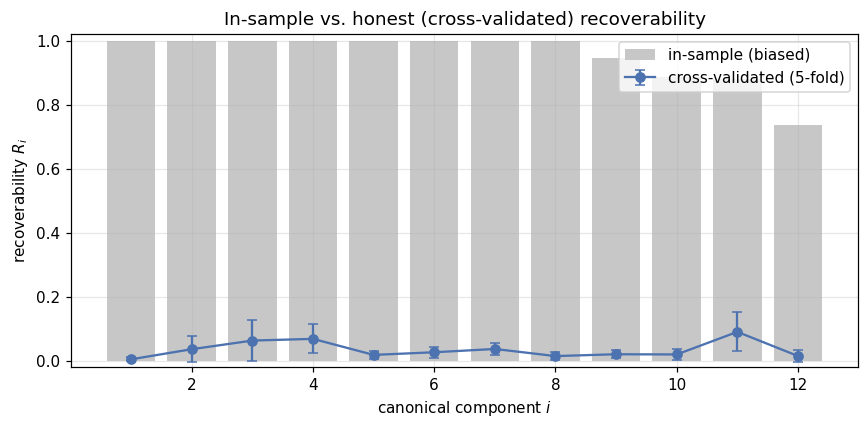

cross-validated recoverability per component:
[0.005 0.036 0.063 0.068 0.018 0.027 0.037 0.015 0.02  0.02  0.09  0.015]


In [11]:
cv = rgit.cross_validated_recoverability(
    G_model, X_model, n_components=N_COMPONENTS,
    n_folds=N_FOLDS, random_state=SEED,
)
cv_mean, cv_std = cv.mean(axis=0), cv.std(axis=0)
comps = spectrum["component"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comps, fit.recoverability, color="#C7C7C7", label="in-sample (biased)")
ax.errorbar(comps, cv_mean, yerr=cv_std, fmt="o-", color="#4C72B0",
            capsize=3, label=f"cross-validated ({N_FOLDS}-fold)")
if truth is not None:
    _, R_true = rgit.true_recoverability(truth)
    ax.plot(np.arange(1, min(len(R_true), N_COMPONENTS) + 1),
            R_true[:N_COMPONENTS], "x--", color="#C44E52", label="ground truth")
ax.set_xlabel("canonical component $i$")
ax.set_ylabel("recoverability $R_i$")
ax.set_ylim(-0.02, 1.02)
ax.set_title("In-sample vs. honest (cross-validated) recoverability")
ax.legend(); plt.tight_layout(); plt.show()

print("cross-validated recoverability per component:")
print(np.array2string(cv_mean, precision=3, suppress_small=True))

## 11 · Permutation test

Permuting patient labels of one modality destroys any real association. The
permutation distribution of the leading canonical correlation gives a null
against which the observed value is tested — does *any* genomic direction beat
chance?

component 1: rho = 1.000   permutation p = 1.0000
component 2: rho = 1.000   permutation p = 1.0000
component 3: rho = 1.000   permutation p = 1.0000


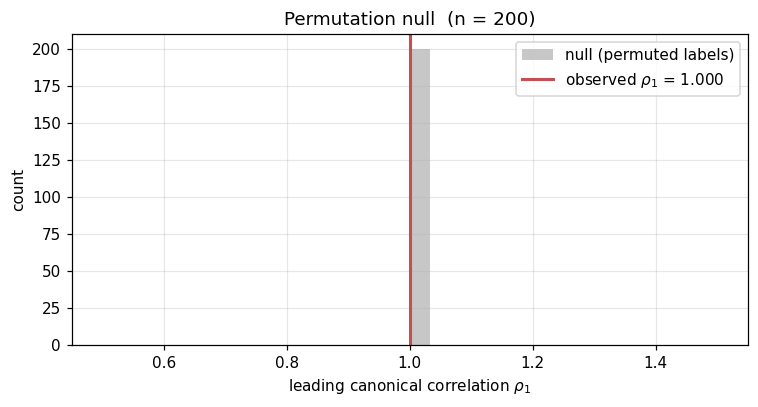

In [12]:
observed, null, pvalues = rgit.permutation_test(
    G_model, X_model, n_components=min(3, N_COMPONENTS),
    n_perm=N_PERM, random_state=SEED,
)
for i, (o, p) in enumerate(zip(observed, pvalues), start=1):
    print(f"component {i}: rho = {o:.3f}   permutation p = {p:.4f}")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(null[:, 0], bins=30, color="#C7C7C7", label="null (permuted labels)")
ax.axvline(observed[0], color="#C44E52", lw=2,
           label=f"observed $\\rho_1$ = {observed[0]:.3f}")
ax.set_xlabel("leading canonical correlation $\\rho_1$")
ax.set_ylabel("count")
ax.set_title(f"Permutation null  (n = {N_PERM})")
ax.legend(); plt.tight_layout(); plt.show()

## 12 · Validation against ground truth

Run only on synthetic data, where the generative parameters are known. We
compare the estimated recoverability spectrum to the closed-form truth, and
measure how well the estimated image-identifiable subspace aligns with the true
shared subspace via the cosines of the principal angles.

In [13]:
if truth is None:
    print("Real data loaded — no ground truth available; skipping validation.")
else:
    rho_true, R_true = rgit.true_recoverability(truth)
    k = truth["k"]

    # estimated subspace vs. true shared genomic subspace
    est_dirs  = to_gene_loadings(fit.genomic_dirs[:, :k])   # (n_genes, k)
    cos_ang   = rgit.subspace_alignment(est_dirs, truth["Wg"])

    print(f"true shared rank k                 : {k}")
    print(f"true   R (first {k+2})            : "
          f"{np.array2string(R_true[:k+2], precision=3, suppress_small=True)}")
    print(f"CV     R (first {k+2})            : "
          f"{np.array2string(cv_mean[:k+2], precision=3, suppress_small=True)}")
    print(f"subspace alignment (cos angles)    : "
          f"{np.array2string(cos_ang, precision=3)}")
    print(f"mean alignment over true subspace  : {cos_ang.mean():.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(np.arange(1, k + 3), R_true[:k + 2], "o--",
                 color="#C44E52", label="ground truth")
    axes[0].plot(np.arange(1, len(cv_mean[:k + 2]) + 1), cv_mean[:k + 2], "s-",
                 color="#4C72B0", label="cross-validated estimate")
    axes[0].set_xlabel("component"); axes[0].set_ylabel("recoverability $R_i$")
    axes[0].set_title("Estimated vs. true recoverability"); axes[0].legend()

    axes[1].bar(np.arange(1, k + 1), cos_ang, color="#55A868")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xlabel("principal direction")
    axes[1].set_ylabel("cosine of principal angle")
    axes[1].set_title("Estimated vs. true genomic subspace")
    plt.tight_layout(); plt.show()

Real data loaded — no ground truth available; skipping validation.


## Summary

- **Imaging covariance** splits into a genomics-driven component and an
  irreducible one — only the former is recoverable.
- The **recoverability spectrum** $\{\rho_i^2\}$ and its directions $\{a_i\}$
  identify a small, low-dimensional genomic subspace that imaging can see; the
  rank limit (Prop. 6 of `main.tex`) caps this regardless of panel size.
- The **posterior covariance** $\Sigma_{G\mid X}$ is a hard floor on residual
  uncertainty for *any* predictor; the Bayes-optimal map $B$ attains it.
- **Cross-validation** corrects the upward bias of in-sample canonical
  correlations, and the **permutation test** establishes significance.
- On synthetic data the cross-validated spectrum and the recovered subspace
  match the known ground truth.

To run on real data, drop two `AnnData` files at `data/genomics.h5ad` and
`data/imaging.h5ad` (patients in `obs`, features in `var`) and re-run — the
synthetic fallback switches off automatically.